This notebook is a simulation of the connectivity problem

I this simulation I rely on a larger number of potential task - picking task batteries of 3 to 28 tasks.

In [270]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.model as model
import cortico_cereb_connectivity.evaluation as con_ev
import OptimalBattery.construct as ct

In [271]:
base_dir = 'Y:/data'

# Make a random task battery with 100 task and plot second moment matrix

In [272]:
seed = 3

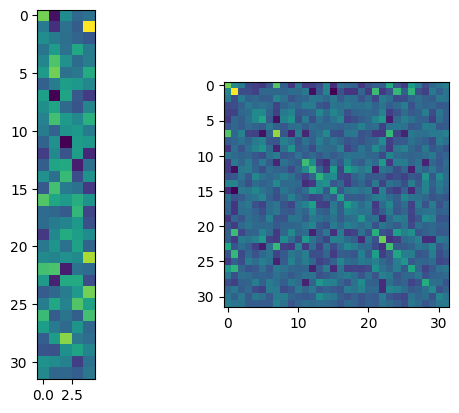

In [284]:
num_task_lib = 32
n_parcels = 5
rng= np.random.default_rng(seed=seed)
V_lib = rng.normal(0,1,(num_task_lib, n_parcels))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

the data in this simulation is 100 tasks x 5 voxels

In [285]:
X_true =V_lib
X_true.shape

(32, 5)

# sample connecitivity weigth matrix from a normal distribution

In [286]:
#sample connecitivity weigth matrix from a normal distribution
n_voxels_y = 5 # number of voxels in the Y space
rng = np.random.default_rng(seed=seed)
W = rng.normal(0,1,(n_parcels, n_voxels_y))

Y_true = X_true @ W
Y_true.shape

(32, 5)

# run the main analysis

In [289]:
battery_sizes = [3,4,6,8,10,14,18,24,28]
metrics = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc']
max_n_task = max(battery_sizes)
n_iter = 5
n_batteries = 10000

In [ ]:
results_df = pd.DataFrame()
for i in range(n_iter):
    print(f"Processing iteration: {i}")
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")

        # Generate possible battery combinations for current battery size and evaluate each battery
        D = ct.build_combinations(G_lib, strategy='random',n_batteries=n_batteries,n_tasks=n_task,seed=i,replacement=False)
        D = D.reset_index(drop=True)

        for metric in metrics:
            if metric == 'random':
                # sample random battery
                index = rng.integers(0,D.shape[0])
                D_metric = D.iloc[[index]]
            else:
                D_metric = D.loc[[D[metric].idxmax()]]
            D_metric = D_metric.reset_index(drop=True)
            top_comb = D_metric['combination'].values[0]         
            xtrain = X_true[top_comb,:]
            xtrain = ut.center_matrix(xtrain,axis=0)
            xtrain = ut.normalize_matrix(xtrain,axis=0)
            ytrain = Y_true[top_comb,:]
            ytrain = ut.center_matrix(ytrain,axis=0)
            ytrain = ut.normalize_matrix(ytrain,axis=0)
            conn_model = getattr(model, 'L2regression')(1000)

            # Fit model, correlate with original weights
            conn_model.fit(xtrain, ytrain)
            coef= conn_model.coef_
            coef_flat = coef.flatten()
            W_flat = W.flatten()
            corrcoef_matrix = np.corrcoef(coef_flat, W_flat)
            pearson_corr = corrcoef_matrix[0, 1]

            D_ev = pd.DataFrame()
            D_ev['iteration'] = [i]
            D_ev['n_task'] = [n_task]
            D_ev['metric'] = [metric]
            D_ev['correlation'] = pearson_corr
            results_df = pd.concat([results_df,D_ev],axis=0)

Processing iteration: 0
Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 10
Processing battery size: 14
Processing battery size: 18


In [ ]:
# # Save results
# results_df.to_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_connectivity.tsv', index=False)
# #load results
# results_df = pd.read_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_connectivity.tsv')

In [282]:
summary_df = results_df.groupby(['n_task', 'metric'])['correlation'].agg(
    mean_correlation='mean',
    sem_correlation=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()

# Ensure numeric data types for plotting
summary_df['n_task'] = pd.to_numeric(summary_df['n_task'], errors='coerce')
summary_df['mean_correlation'] = pd.to_numeric(summary_df['mean_correlation'], errors='coerce')
summary_df['sem_correlation'] = pd.to_numeric(summary_df['sem_correlation'], errors='coerce')


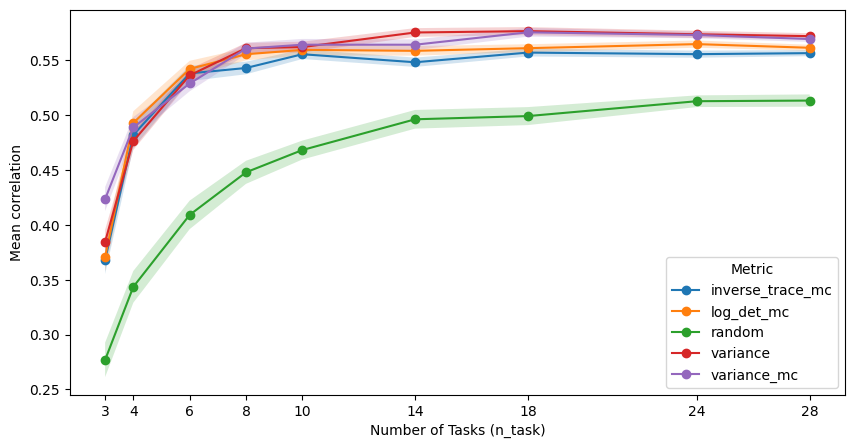

In [283]:
plt.figure(figsize=(10, 5))
for metric in summary_df['metric'].unique():
    subset = summary_df[summary_df['metric'] == metric]
    plt.plot(subset['n_task'], subset['mean_correlation'], marker='o', label=metric)
    plt.fill_between(subset['n_task'],
                     subset['mean_correlation'] - subset['sem_correlation'],
                     subset['mean_correlation'] + subset['sem_correlation'],
                     alpha=0.2) 

plt.xlabel("Number of Tasks (n_task)")
plt.xticks(battery_sizes)
plt.ylabel("Mean correlation")
plt.legend(title="Metric")
plt.show()